In [ ]:
#Task 0 a)
Name: Netflix Movies and TV Shows
Source: Kaggle
https://www.kaggle.com/datasets/shivamb/netflix-shows


In [ ]:
#b) Dataset Description

I chose the Netflix Movies and TV Shows dataset from Kaggle.

The dataset contains information about movies and TV shows available on Netflix. It includes variables such as:
Title, type (Movie or TV Show), country, release_year, rating, duration, listed_in (genre).

This dataset contains about 8800 rows.

In this project, I plan to analyse:
How the number of movies and TV shows has changed over time, which countries produce the most content, 
the most common genres and ratings

This will help understand trends in Netflix content.

In [2]:
#c) 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


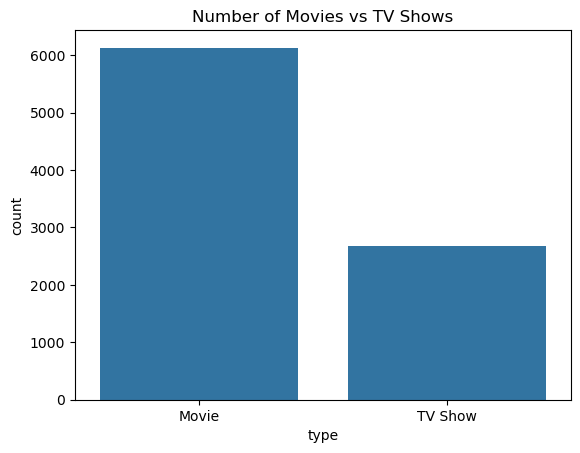

In [4]:
sns.countplot(x="type", data=df)
plt.title("Number of Movies vs TV Shows")
plt.show()

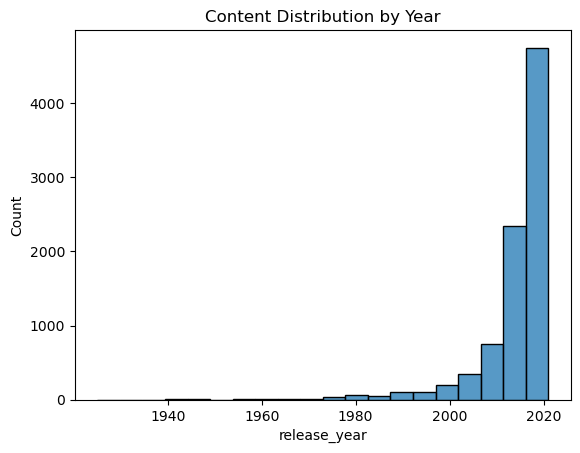

In [5]:
sns.histplot(df["release_year"], bins=20)
plt.title("Content Distribution by Year")
plt.show()

In [11]:
#Task 1 a)
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("API_KEY")

print(api_key[:5] + "...")

2bac2...


In [16]:
# Task 2 a)
import os
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("API_KEY")

In [13]:
# Task 2


In [17]:
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

all_data = []

for ticker in tickers:
    url = "http://api.marketstack.com/v1/eod"
    
    params = {
        "access_key": api_key,
        "symbols": ticker,
        "date_from": "2026-03-01",
        "date_to": "2026-03-31",
        "limit": 100
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    if "data" in data:
        all_data.extend(data["data"])

In [18]:
# b)
df = pd.DataFrame(all_data)

print(df.head())

     open    high     low   close      volume  adj_high  adj_low  adj_close  \
0  549.98  573.69  546.77  572.13  32809500.0  573.6900   546.77     572.13   
1  536.38  539.55  528.54  536.38  22758800.0  539.5500   528.54     536.38   
2  540.10  543.60  520.26  525.72  29980300.0  543.5999   520.26     525.72   
3  582.49  583.00  543.35  547.54  35664700.0  583.0000   543.35     547.54   
4  598.74  603.62  593.40  594.89  12161179.0  603.6700   593.40     594.89   

   adj_open  adj_volume  split_factor  dividend symbol exchange  \
0    549.98  32898272.0           1.0       0.0   META     ARCX   
1    536.38  22795203.0           1.0       0.0   META     ARCX   
2    540.10  30133010.0           1.0       0.0   META     ARCX   
3    582.49  35780131.0           1.0       0.0   META     ARCX   
4    598.74  12585031.0           1.0       0.0   META     ARCX   

                       date  
0  2026-03-31T00:00:00+0000  
1  2026-03-30T00:00:00+0000  
2  2026-03-27T00:00:00+0000  
3 

In [19]:
df = df[["symbol", "date", "open", "high", "low", "close", "volume"]]

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["symbol", "date"])

print(df.head())

   symbol                      date     open     high     low   close  \
43   AAPL 2026-03-02 00:00:00+00:00  262.440  266.530  260.20  264.72   
42   AAPL 2026-03-03 00:00:00+00:00  263.480  265.560  260.13  263.75   
41   AAPL 2026-03-04 00:00:00+00:00  264.650  266.150  261.42  262.52   
40   AAPL 2026-03-05 00:00:00+00:00  260.745  261.555  257.25  260.29   
39   AAPL 2026-03-06 00:00:00+00:00  258.740  258.760  254.37  257.46   

        volume  
43  41576035.0  
42  37994695.0  
41  39258957.0  
40  49424671.0  
39  40628988.0  


In [20]:
# c)
summary_stats = df.groupby("symbol")["close"].describe()

print(summary_stats)

        count        mean        std     min       25%      50%       75%  \
symbol                                                                      
AAPL     22.0  254.906364   5.510351  246.63  250.4625  253.340  260.1875   
AMZN     22.0  209.995000   4.643217  199.34  207.8200  209.700  213.0700   
GOOG     22.0  297.980455  10.928636  273.14  291.7675  302.335  305.9400   
META     22.0  614.990909  41.309579  525.72  593.9675  619.170  652.0175   
NFLX     22.0   95.076364   2.512109   90.92   93.3350   94.795   97.0525   

           max  
symbol          
AAPL    264.72  
AMZN    218.94  
GOOG    309.41  
META    667.73  
NFLX     99.17  


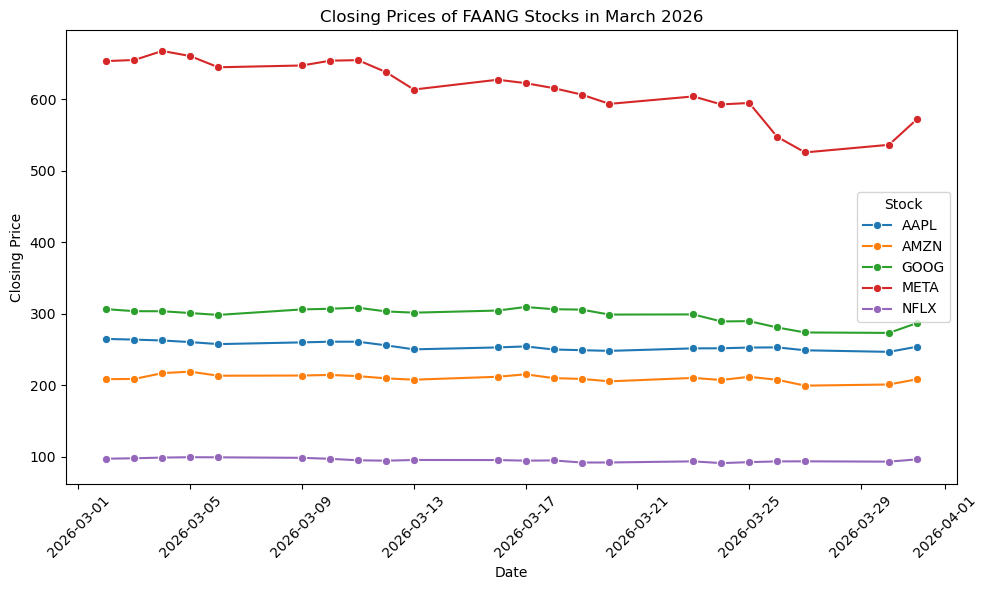

In [21]:
# Task 3 a)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="date", y="close", hue="symbol", marker="o")

plt.title("Closing Prices of FAANG Stocks in March 2026")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.legend(title="Stock")
plt.tight_layout()
plt.show()

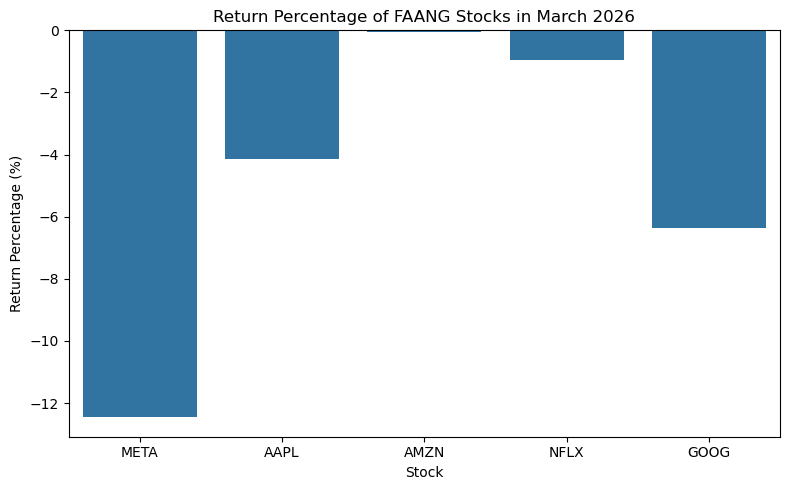

In [22]:
# b)
plt.figure(figsize=(8, 5))
sns.barplot(data=returns_df, x="symbol", y="return_pct")

plt.title("Return Percentage of FAANG Stocks in March 2026")
plt.xlabel("Stock")
plt.ylabel("Return Percentage (%)")
plt.tight_layout()
plt.show()

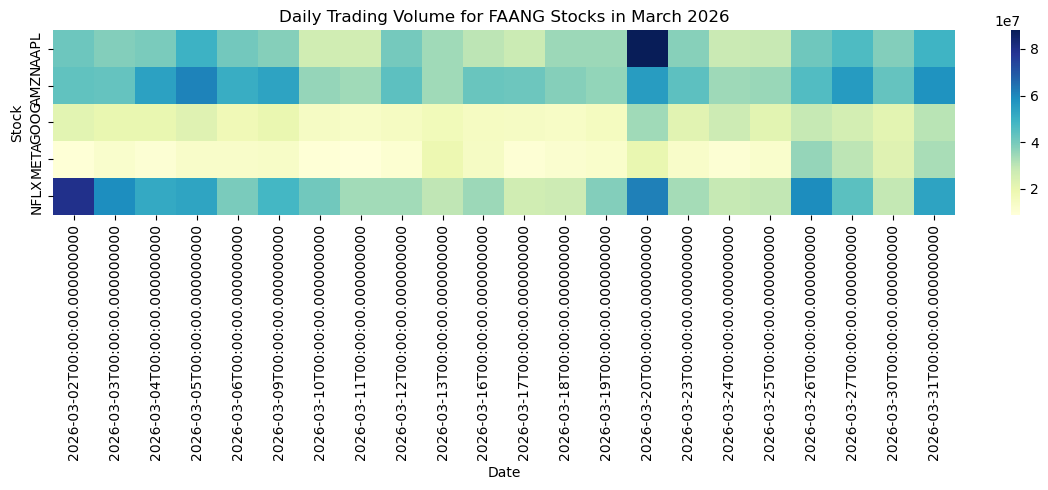

In [26]:
# c)
volume_pivot = df.pivot(index="symbol", columns="date", values="volume")
plt.figure(figsize=(12, 5))
sns.heatmap(volume_pivot, cmap="YlGnBu")

plt.title("Daily Trading Volume for FAANG Stocks in March 2026")
plt.xlabel("Date")
plt.ylabel("Stock")
plt.tight_layout()
plt.show()

In [27]:
# Task 4 a)
import os
import json

os.makedirs("exports", exist_ok=True)

with open("exports/stockdata.json", "w") as f:
    json.dump(all_data, f)

In [29]:
# b)
df.to_csv("exports/stockdata.csv", index=False)

In [30]:
# c)
with open("exports/stockdata.json", "r") as f:
    json_loaded = json.load(f)

json_df = pd.DataFrame(json_loaded)

print("JSON loaded:")
print(json_df.head())

JSON loaded:
     open    high     low   close      volume  adj_high  adj_low  adj_close  \
0  549.98  573.69  546.77  572.13  32809500.0  573.6900   546.77     572.13   
1  536.38  539.55  528.54  536.38  22758800.0  539.5500   528.54     536.38   
2  540.10  543.60  520.26  525.72  29980300.0  543.5999   520.26     525.72   
3  582.49  583.00  543.35  547.54  35664700.0  583.0000   543.35     547.54   
4  598.74  603.62  593.40  594.89  12161179.0  603.6700   593.40     594.89   

   adj_open  adj_volume  split_factor  dividend symbol exchange  \
0    549.98  32898272.0           1.0       0.0   META     ARCX   
1    536.38  22795203.0           1.0       0.0   META     ARCX   
2    540.10  30133010.0           1.0       0.0   META     ARCX   
3    582.49  35780131.0           1.0       0.0   META     ARCX   
4    598.74  12585031.0           1.0       0.0   META     ARCX   

                       date  
0  2026-03-31T00:00:00+0000  
1  2026-03-30T00:00:00+0000  
2  2026-03-27T00:00

In [31]:
csv_df = pd.read_csv("exports/stockdata.csv")

print("\nCSV loaded:")
print(csv_df.head())


CSV loaded:
  symbol                       date     open     high     low   close  \
0   AAPL  2026-03-02 00:00:00+00:00  262.440  266.530  260.20  264.72   
1   AAPL  2026-03-03 00:00:00+00:00  263.480  265.560  260.13  263.75   
2   AAPL  2026-03-04 00:00:00+00:00  264.650  266.150  261.42  262.52   
3   AAPL  2026-03-05 00:00:00+00:00  260.745  261.555  257.25  260.29   
4   AAPL  2026-03-06 00:00:00+00:00  258.740  258.760  254.37  257.46   

       volume  
0  41576035.0  
1  37994695.0  
2  39258957.0  
3  49424671.0  
4  40628988.0  


In [36]:
# Task 5 a)

import sqlite3
import pandas as pd

conn = sqlite3.connect("northwind.db")

query = "SELECT name FROM sqlite_master WHERE type='table';"

tables = pd.read_sql_query(query, conn)

print(tables)

                    name
0             Categories
1        sqlite_sequence
2   CustomerCustomerDemo
3   CustomerDemographics
4              Customers
5              Employees
6    EmployeeTerritories
7          Order Details
8                 Orders
9               Products
10               Regions
11              Shippers
12             Suppliers
13           Territories


In [37]:
# b)
query = """
SELECT ProductName, UnitPrice, UnitsInStock
FROM Products
WHERE UnitPrice > 30
"""

df_products = pd.read_sql_query(query, conn)

print(df_products)

                   ProductName  UnitPrice  UnitsInStock
0   Northwoods Cranberry Sauce      40.00             6
1              Mishi Kobe Niku      97.00            29
2                        Ikura      31.00            31
3    Queso Manchego La Pastora      38.00            86
4                 Alice Mutton      39.00             0
5             Carnarvon Tigers      62.50            42
6       Sir Rodney's Marmalade      81.00            40
7          Gumbär Gummibärchen      31.23            15
8           Schoggi Schokolade      43.90            49
9            Rössle Sauerkraut      45.60            26
10     Thüringer Rostbratwurst     123.79             0
11          Mascarpone Fabioli      32.00             9
12               Côte de Blaye     263.50            17
13                 Ipoh Coffee      46.00            17
14       Manjimup Dried Apples      53.00            20
15               Perth Pasties      32.80             0
16      Gnocchi di nonna Alice      38.00       

In [38]:
# c)
query = """
SELECT 
    c.CompanyName,
    o.OrderID,
    o.OrderDate,
    o.ShipCountry,
    od.UnitPrice * od.Quantity AS LineTotal
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN "Order Details" od ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany'
"""

df_orders = pd.read_sql_query(query, conn)

print(df_orders)

              CompanyName  OrderID            OrderDate ShipCountry  LineTotal
0      Toms Spezialitäten    10249           2016-07-05     Germany      167.4
1      Toms Spezialitäten    10249           2016-07-05     Germany     1696.0
2      Ottilies Käseladen    10260           2016-07-19     Germany      123.2
3      Ottilies Käseladen    10260           2016-07-19     Germany      780.0
4      Ottilies Käseladen    10260           2016-07-19     Germany      591.0
...                   ...      ...                  ...         ...        ...
80668    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany      864.0
80669    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany      735.0
80670    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany       75.0
80671    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany      500.0
80672    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany       77.5

[80673 rows x 5 columns]


In [40]:
# Task 6 a)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

orders_per_customer = (
    df_orders.groupby("CompanyName")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="order_count")
)

print(orders_per_customer)

               CompanyName  order_count
0               QUICK-Stop           56
1       Ottilies Käseladen           40
2                       IT           40
3           Frankenversand           38
4          Königlich Essen           36
5  Great Lakes Food Market           35
6       Toms Spezialitäten           35
7      Lehmanns Marktstand           34
8            B's Beverages           32
9           Island Trading           31


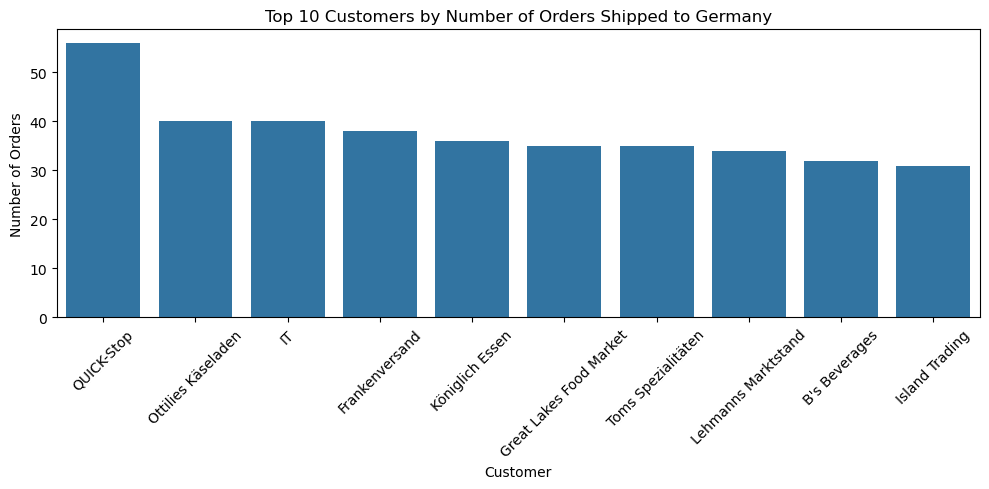

In [41]:
plt.figure(figsize=(10, 5))
sns.barplot(data=orders_per_customer, x="CompanyName", y="order_count")

plt.title("Top 10 Customers by Number of Orders Shipped to Germany")
plt.xlabel("Customer")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
# b)
daily_sales = (
    df_orders.groupby("OrderDate")["LineTotal"]
    .sum()
    .reset_index()
)

daily_sales["OrderDate"] = pd.to_datetime(daily_sales["OrderDate"], format="mixed")

print(daily_sales.head())

            OrderDate  LineTotal
0 2012-07-16 00:26:10   21857.43
1 2012-07-18 22:31:52   53885.01
2 2012-07-25 23:14:37   18591.01
3 2012-07-30 01:48:16   60918.92
4 2012-07-31 05:55:45   55931.37


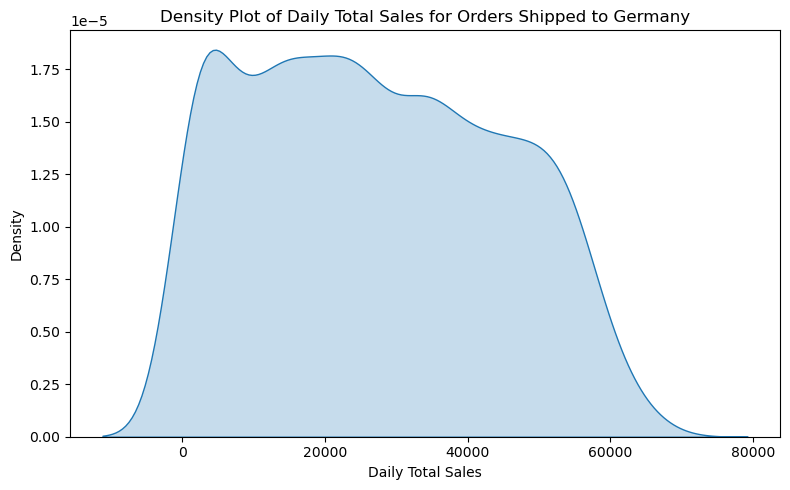

In [44]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=daily_sales, x="LineTotal", fill=True)

plt.title("Density Plot of Daily Total Sales for Orders Shipped to Germany")
plt.xlabel("Daily Total Sales")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [45]:
# c)
query = """
SELECT 
    c.CategoryName,
    SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories c ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
ORDER BY TotalRevenue DESC
"""

df_category_revenue = pd.read_sql_query(query, conn)

print(df_category_revenue)

     CategoryName  TotalRevenue
0       Beverages   92181842.95
1     Confections   66347544.94
2    Meat/Poultry   64896314.41
3  Dairy Products   58034940.00
4      Condiments   55802774.45
5         Seafood   49931965.52
6         Produce   32706403.90
7  Grains/Cereals   28573512.55


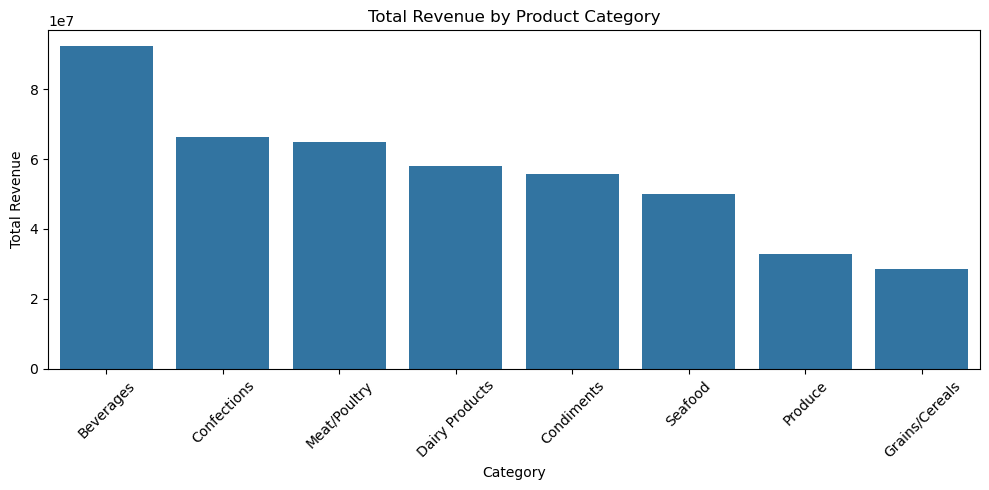

In [46]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_category_revenue, x="CategoryName", y="TotalRevenue")

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
# Task 7 a)
products_query = "SELECT * FROM Products"
categories_query = "SELECT * FROM Categories"

df_products = pd.read_sql_query(products_query, conn)
df_categories = pd.read_sql_query(categories_query, conn)

print("Products:")
print(df_products.head())

Products:
   ProductID                   ProductName  SupplierID  CategoryID  \
0          1                          Chai           1           1   
1          2                         Chang           1           1   
2          3                 Aniseed Syrup           1           2   
3          4  Chef Anton's Cajun Seasoning           2           2   
4          5        Chef Anton's Gumbo Mix           2           2   

       QuantityPerUnit  UnitPrice  UnitsInStock  UnitsOnOrder  ReorderLevel  \
0   10 boxes x 20 bags      18.00            39             0            10   
1   24 - 12 oz bottles      19.00            17            40            25   
2  12 - 550 ml bottles      10.00            13            70            25   
3       48 - 6 oz jars      22.00            53             0             0   
4             36 boxes      21.35             0             0             0   

  Discontinued  
0            0  
1            0  
2            0  
3            0  
4        

In [49]:
print("\nCategories:")
print(df_categories.head())


Categories:
   CategoryID    CategoryName  \
0           1       Beverages   
1           2      Condiments   
2           3     Confections   
3           4  Dairy Products   
4           5  Grains/Cereals   

                                         Description  \
0        Soft drinks, coffees, teas, beers, and ales   
1  Sweet and savory sauces, relishes, spreads, an...   
2                Desserts, candies, and sweet breads   
3                                            Cheeses   
4                Breads, crackers, pasta, and cereal   

                                             Picture  
0  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...  
1  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...  
2  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...  
3  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...  
4  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...  


In [50]:
# b)
df_joined = pd.merge(df_products, df_categories, on="CategoryID", how="inner")

print(df_joined.head())

   ProductID                   ProductName  SupplierID  CategoryID  \
0          1                          Chai           1           1   
1          2                         Chang           1           1   
2          3                 Aniseed Syrup           1           2   
3          4  Chef Anton's Cajun Seasoning           2           2   
4          5        Chef Anton's Gumbo Mix           2           2   

       QuantityPerUnit  UnitPrice  UnitsInStock  UnitsOnOrder  ReorderLevel  \
0   10 boxes x 20 bags      18.00            39             0            10   
1   24 - 12 oz bottles      19.00            17            40            25   
2  12 - 550 ml bottles      10.00            13            70            25   
3       48 - 6 oz jars      22.00            53             0             0   
4             36 boxes      21.35             0             0             0   

  Discontinued CategoryName  \
0            0    Beverages   
1            0    Beverages   
2          

In [51]:
# c)
import time

start_sql = time.time()

query_sql = """
SELECT 
    c.CategoryName,
    SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories c ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
ORDER BY TotalRevenue DESC
"""

df_sql_result = pd.read_sql_query(query_sql, conn)

end_sql = time.time()
sql_time = end_sql - start_sql

print("SQL result:")
print(df_sql_result)

print(f"\nSQL execution time: {sql_time:.6f} seconds")

SQL result:
     CategoryName  TotalRevenue
0       Beverages   92181842.95
1     Confections   66347544.94
2    Meat/Poultry   64896314.41
3  Dairy Products   58034940.00
4      Condiments   55802774.45
5         Seafood   49931965.52
6         Produce   32706403.90
7  Grains/Cereals   28573512.55

SQL execution time: 0.258988 seconds


In [52]:
start_py = time.time()

df_order_details = pd.read_sql_query('SELECT * FROM "Order Details"', conn)
df_products_full = pd.read_sql_query("SELECT * FROM Products", conn)
df_categories_full = pd.read_sql_query("SELECT * FROM Categories", conn)

df_merge1 = pd.merge(df_order_details, df_products_full, on="ProductID", how="inner")

df_merge2 = pd.merge(df_merge1, df_categories_full, on="CategoryID", how="inner")

df_merge2["Revenue"] = df_merge2["UnitPrice_x"] * df_merge2["Quantity"]

df_python_result = (
    df_merge2.groupby("CategoryName")["Revenue"]
    .sum()
    .reset_index(name="TotalRevenue")
    .sort_values("TotalRevenue", ascending=False)
)

end_py = time.time()
python_time = end_py - start_py

print("Python/pandas result:")
print(df_python_result)

print(f"\nPython execution time: {python_time:.6f} seconds")

Python/pandas result:
     CategoryName  TotalRevenue
0       Beverages   92181842.95
2     Confections   66347544.94
5    Meat/Poultry   64896314.41
3  Dairy Products   58034940.00
1      Condiments   55802774.45
7         Seafood   49931965.52
6         Produce   32706403.90
4  Grains/Cereals   28573512.55

Python execution time: 0.584977 seconds


In [55]:
# In my test times for SQL and Python: 
# SQL: 0.258988 seconds
# Python: 0.584977
# And as you can see the SQL is about twice as fast as the Python

In [56]:
# Task 8 a)
import pandas as pd

wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

In [57]:
print("Wide data before conversion:")
print(wide_data)

wide_to_long = pd.melt(
    wide_data,
    id_vars="store",
    var_name="quarter",
    value_name="sales"
)

print("\nWide data after conversion to long format:")
print(wide_to_long)

Wide data before conversion:
      store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500

Wide data after conversion to long format:
       store   quarter  sales
0   Helsinki  Q1_sales  12000
1    Tampere  Q1_sales   8500
2      Turku  Q1_sales   9200
3   Helsinki  Q2_sales  13500
4    Tampere  Q2_sales   9100
5      Turku  Q2_sales   9800
6   Helsinki  Q3_sales  11800
7    Tampere  Q3_sales   8800
8      Turku  Q3_sales  10100
9   Helsinki  Q4_sales  15000
10   Tampere  Q4_sales  10200
11     Turku  Q4_sales  11500


In [58]:
# b)
print("Long data before conversion:")
print(long_data)

long_to_wide = long_data.pivot(
    index="month",
    columns="product",
    values="units_sold"
)

print("\nLong data after conversion to wide format:")
print(long_to_wide)

Long data before conversion:
  month product  units_sold
0   Jan  Laptop          45
1   Jan   Phone         120
2   Feb  Laptop          50
3   Feb   Phone         110
4   Mar  Laptop          55
5   Mar   Phone         130

Long data after conversion to wide format:
product  Laptop  Phone
month                 
Feb          50    110
Jan          45    120
Mar          55    130


In [60]:
# c)
wide_back = wide_to_long.pivot(
    index="store",
    columns="quarter",
    values="sales"
).reset_index()

print("Original wide_data:")
print(wide_data)

print("\nConverted back to wide:")
print(wide_back)

Original wide_data:
      store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500

Converted back to wide:
quarter     store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0        Helsinki     12000     13500     11800     15000
1         Tampere      8500      9100      8800     10200
2           Turku      9200      9800     10100     11500


In [61]:
long_back = long_to_wide.reset_index().melt(
    id_vars="month",
    var_name="product",
    value_name="units_sold"
)

print("Original long_data:")
print(long_data)

print("\nConverted back to long:")
print(long_back)

Original long_data:
  month product  units_sold
0   Jan  Laptop          45
1   Jan   Phone         120
2   Feb  Laptop          50
3   Feb   Phone         110
4   Mar  Laptop          55
5   Mar   Phone         130

Converted back to long:
  month product  units_sold
0   Feb  Laptop          50
1   Jan  Laptop          45
2   Mar  Laptop          55
3   Feb   Phone         110
4   Jan   Phone         120
5   Mar   Phone         130


In [ ]:
AI statement:
As for the use of AI i did use AI in almost every part of the assignment, but manily as a helping tool.
I used claude AI to help me woth understanding the code and also correcting aswell as explaning error codes and so forth.
I did try to do every task without AI but when i got stuck or needed help i pivoted.